# HET quick-look presentation playground

This notebook has a short operational path followed by optional evidence
inspection. Configure the raw and trace roots once, inspect the exposure
inventory, select a row, and make a quick look. The package retains the
detector, trace, topology, extraction, amplifier, and channel evidence for
diagnostic work below.


## 1. Configure the session

`QuicklookSite` expands the paths once and keeps the instrument-specific
discovery configuration for the notebook session. The package must be
installed, preferably in editable mode while developing it.


In [1]:
from hetquicklook import QuicklookSite

ql = QuicklookSite(
    raw_roots={
        "lrs2": "~/data/LRS2",
        "virus": "~/data/VIRUS",
    },
)


## 2. Choose a date and inspect the exposure inventory

The table has one row per encoded exposure ID, including multiple exposure IDs
inside one observation archive. Rows use zero-based Python indexing.


In [2]:
night = ql.night("20260609", instrument="virus")
night


Row,Observation,Exposure ID,UTC/time,Frame type,OBJECT,Quick-look kind,Calibration / standard,IFU slot,Exposure time [s],Program,Amplifiers/components
0,virus0000001,20260609T022141.1,2026-06-09 02:22:52.831021,twi,skyflat,science,—,"013, 014, 015, 016, 021, 022, 023, 024, … (+67 more)",14.599454208,—,"013LL, 013LU, 013RL, 013RU, 014LL, 014LU, 014RL, 014RU, … (+292 more)"
1,virus0000002,20260609T022257.0,2026-06-09 02:24:10.965161,twi,skyflat,science,—,"013, 014, 015, 016, 021, 022, 023, 024, … (+67 more)",17.621405184,—,"013LL, 013LU, 013RL, 013RU, 014LL, 014LU, 014RL, 014RU, … (+292 more)"
2,virus0000003,20260609T022415.2,2026-06-09 02:25:32.719251,twi,skyflat,science,—,"013, 014, 015, 016, 021, 022, 023, 024, … (+67 more)",21.027815936,—,"013LL, 013LU, 013RL, 013RU, 014LL, 014LU, 014RL, 014RU, … (+292 more)"
3,virus0000004,20260609T022536.9,2026-06-09 02:26:58.844379,twi,skyflat,science,—,"013, 014, 015, 016, 021, 022, 023, 024, … (+67 more)",25.271197184,—,"013LL, 013LU, 013RL, 013RU, 014LL, 014LU, 014RL, 014RU, … (+292 more)"
4,virus0000005,20260609T022703.0,2026-06-09 02:28:32.353269,twi,skyflat,science,—,"013, 014, 015, 016, 021, 022, 023, 024, … (+67 more)",32.900204032,—,"013LL, 013LU, 013RL, 013RU, 014LL, 014LU, 014RL, 014RU, … (+292 more)"
5,virus0000006,20260609T031649.6,2026-06-09 03:18:52.012446,sci,WD1327-083_052_E,standard,standard: WD1327-083,"013, 014, 015, 016, 021, 022, 023, 024, … (+67 more)",67.399394048,—,"013LL, 013LU, 013RL, 013RU, 014LL, 014LU, 014RL, 014RU, … (+292 more)"
6,virus0000006,20260609T031859.3,2026-06-09 03:21:04.436268,sci,WD1327-083_052_E,standard,standard: WD1327-083,"013, 014, 015, 016, 021, 022, 023, 024, … (+67 more)",67.448336384,—,"013LL, 013LU, 013RL, 013RU, 014LL, 014LU, 014RL, 014RU, … (+292 more)"
7,virus0000006,20260609T032112.2,2026-06-09 03:23:15.417278,sci,WD1327-083_052_E,standard,standard: WD1327-083,"013, 014, 015, 016, 021, 022, 023, 024, … (+67 more)",67.899279872,—,"013LL, 013LU, 013RL, 013RU, 014LL, 014LU, 014RL, 014RU, … (+292 more)"
8,virus0000007,20260609T032815.4,2026-06-09 04:02:20.707577,sci,parallel,science,—,"013, 014, 015, 016, 021, 022, 023, 024, … (+67 more)",67.899279872,PSU26-2-015,"013LL, 013LU, 013RL, 013RU, 014LL, 014LU, 014RL, 014RU, … (+292 more)"
9,virus0000008,20260609T040740.1,2026-06-09 04:41:45.261471,sci,parallel,science,—,"013, 014, 015, 016, 021, 022, 023, 024, … (+67 more)",2007.521087744,UT26-2-003,"013LL, 013LU, 013RL, 013RU, 014LL, 014LU, 014RL, 014RU, … (+292 more)"


## 3. Select one exposure and make the quick look

Classification chooses the flat or standard-star workflow automatically. An
unsupported exposure raises a descriptive error rather than selecting a
workflow by guesswork.


In [3]:
# Example recognized standard-star row for the date above; choose another row from the table as needed.
exposure = night[25]
exposure


QuicklookExposure(row=25, exposure_id='20260609T233737.0', instrument='virus', kind='flat')

In [4]:
product = exposure.quicklook()


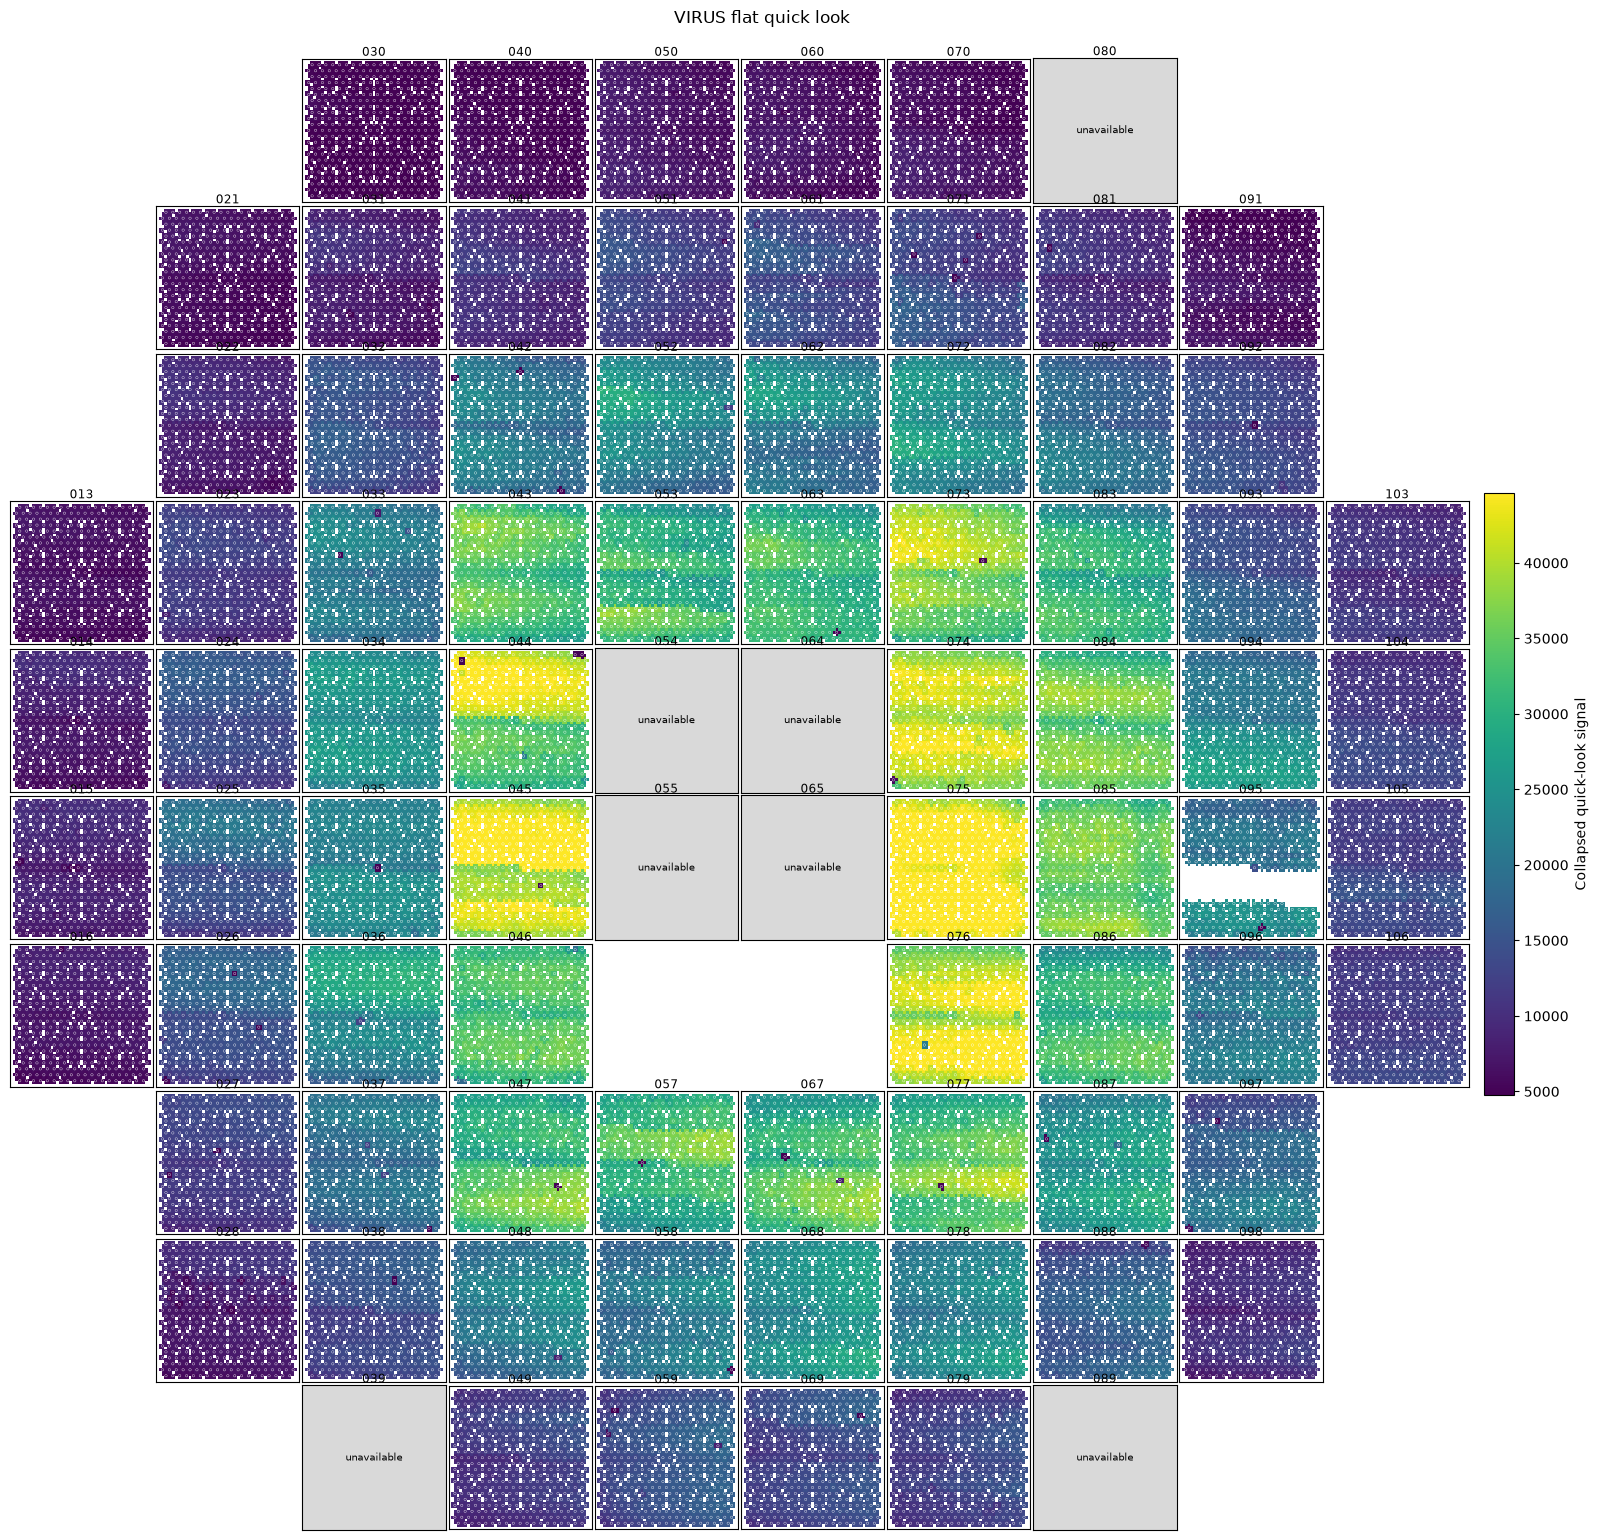

In [6]:
figure = product.plot()


## Advanced / diagnostic inspection

The cells below are optional. They use the objects retained by the normal
workflow; they do not repeat detector reduction, topology construction, or
LRS2 channel composition.


In [9]:
print("Underlying observation:", exposure.observation)
print("Archive:", exposure.observation.archive_path)
print("Raw exposure:", exposure.raw_exposure)
print("Metadata:", exposure.metadata)
print("Classification:", exposure.classification)


Underlying observation: Observation(discovered=DiscoveredObservation(archive_path=PosixPath('/Users/grz85/data/LRS2/20260512/lrs2/lrs20000020.tar'), date=datetime.date(2026, 5, 12), instrument=<Instrument.LRS2: 'lrs2'>, outer_tar_member=None), members=(ArchiveMember(archive_path=PosixPath('/Users/grz85/data/LRS2/20260512/lrs2/lrs20000020.tar'), member_name='lrs20000020/exp01/lrs2/20260512T093727.5_056LL_sci.fits', size=4409280, outer_tar_member=None, identity=RawFrameIdentity(exposure_id='20260512T093727.5', amplifier_token='056LL', frame_type='sci'), parse_error=None), ArchiveMember(archive_path=PosixPath('/Users/grz85/data/LRS2/20260512/lrs2/lrs20000020.tar'), member_name='lrs20000020/exp01/lrs2/20260512T093727.5_056LU_sci.fits', size=4409280, outer_tar_member=None, identity=RawFrameIdentity(exposure_id='20260512T093727.5', amplifier_token='056LU', frame_type='sci'), parse_error=None), ArchiveMember(archive_path=PosixPath('/Users/grz85/data/LRS2/20260512/lrs2/lrs20000020.tar'), membe

In [10]:
if product.instrument.value == "lrs2":
    print("Channels:", tuple(product.channels))
    print("Available amplifiers:", tuple(product.amplifier_evidence))
else:
    print("VIRUS IFUs:", tuple(product.ifus))
    print("Available amplifiers:", tuple(product.amplifier_evidence))


Channels: ('UV', 'Orange', 'Red', 'Far-Red')
Available amplifiers: ('056LL', '056LU', '056RL', '056RU', '066LL', '066LU', '066RL', '066RU')


In [11]:
# One amplifier's complete evidence tree.
if product.amplifier_evidence:
    token = next(iter(product.amplifier_evidence))
    amplifier_evidence = product.amplifier_evidence[token]
    print("Selected amplifier:", token)
    print("Raw provenance:", amplifier_evidence.loaded.provenance)
    print("Detector result:", amplifier_evidence.detector)
    print("Physical identity:", amplifier_evidence.topology.physical_identity)
    print("Trace provenance:", amplifier_evidence.topology.trace_provenance)
    print("Position provenance:", amplifier_evidence.topology.position_provenance)
    print("Spatial product:", amplifier_evidence.product)
else:
    print("No amplifier evidence was produced.")


Selected amplifier: 056LL
Raw provenance: (PosixPath('/Users/grz85/data/LRS2/20260512/lrs2/lrs20000020.tar'), None, 'lrs20000020/exp01/lrs2/20260512T093727.5_056LL_sci.fits')
Detector result: AlgorithmResult(kind='detector_reduction', version='detector-2.0', arrays={'overscan_model': array([911.18985912, 910.81702428, 911.20920186, ..., 912.64506868,
       912.12109494, 912.31767871], shape=(1032,)), 'overscan_corrected_image': array([[ 3.81014088,  7.81014088,  9.81014088, ..., -2.18985912,
         0.81014088,  2.81014088],
       [ 7.18297572, -5.81702428,  3.18297572, ...,  0.18297572,
        -0.81702428,  7.18297572],
       [11.79079814,  2.79079814, -0.20920186, ...,  0.79079814,
        -3.20920186,  3.79079814],
       ...,
       [ 1.35493132,  2.35493132,  5.35493132, ...,  1.35493132,
         3.35493132,  7.35493132],
       [ 6.87890506, -1.12109494,  1.87890506, ...,  3.87890506,
         9.87890506,  1.87890506],
       [ 0.68232129,  0.68232129,  0.68232129, ...,  2.

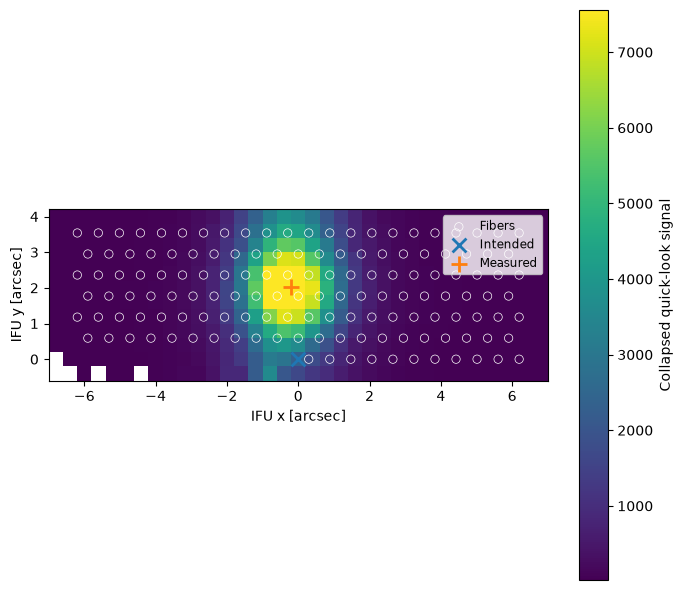

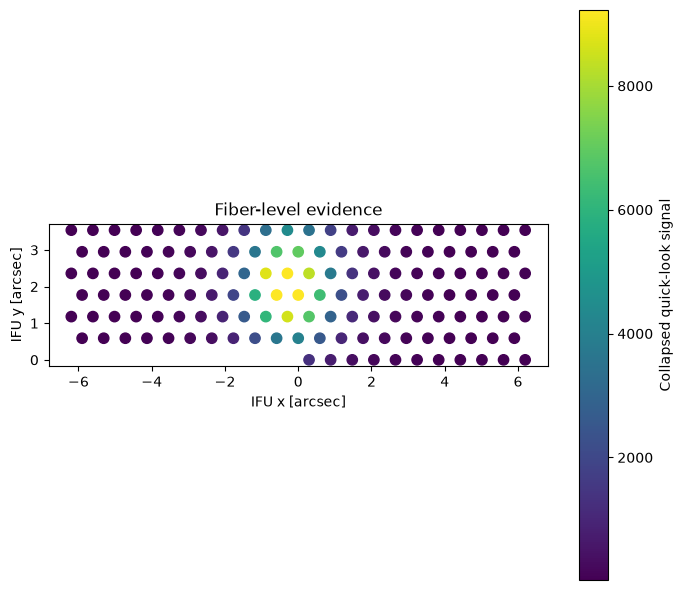

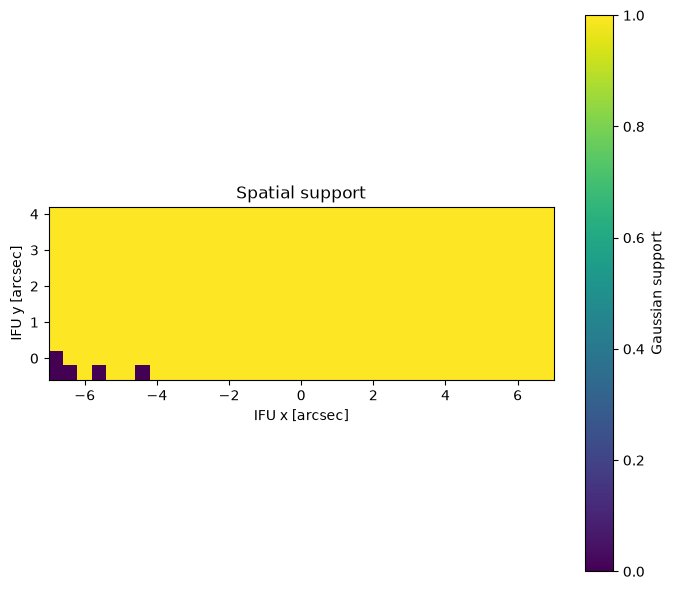

In [12]:
if product.amplifier_evidence:
    from hetquicklook.visualization import (
        plot_fiber_values,
        plot_spatial_image,
        plot_spatial_support,
    )

    amplifier_product = amplifier_evidence.product
    plot_spatial_image(amplifier_product)
    plot_fiber_values(amplifier_product)
    plot_spatial_support(amplifier_product)
else:
    print("No amplifier product is available.")


### VIRUS IFU selection

A VIRUS exposure can contain several IFUs. The high-level product keeps them
as a collection and never chooses one arbitrarily. When more than one is
present, select the physical IFU explicitly for its amplifier evidence view.


In [17]:
if product.instrument.value == "virus":
    print("Available IFUs:", tuple(product.ifus))
    # Example:
    figure = product.plot(ifu="074")


### Presentation experiments

Display choices can be changed without changing the stored scientific
results. For example, a different percentile stretch can be used for
inspection or a figure can be saved after reviewing it.


In [15]:
if product.instrument.value == "virus" or len(product.ifus) == 1:
    experiment_figure = product.plot(
        percentiles=(1.0, 99.0),
        show_fibers=True,
    )
    # experiment_figure.savefig("quicklook_experiment.png", dpi=160, bbox_inches="tight")
else:
    print("Select a VIRUS IFU before plotting a multi-IFU exposure.")


Select a VIRUS IFU before plotting a multi-IFU exposure.


The lower-level workflow APIs remain available for tests and
specialized investigations. Use them when a prepared detector array and
amplifier-level `FiberTopology` are the objects of interest.
